# Sentiment and Thematic Analysis

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
sys.path.append(os.path.abspath(".."))
from transformers import pipeline
from src.datapreprocessing import load_data

## Model Initialization

In [3]:
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 634.93it/s]


## Load Cleaned Dataset

In [4]:
df = load_data("../data/processed/cleaned_bank_reviews.csv")

## Predict Review Sentiment

In [5]:
sentiments = []
confidence_scores = []

for review in df["review"]:

    result = sentiment_pipeline(str(review))[0]

    label = result["label"]
    score = result["score"]

    if score < 0.60:
        sentiment = "Neutral"
    elif label == "POSITIVE":
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    sentiments.append(sentiment)
    confidence_scores.append(score)

df["sentiment"] = sentiments
df["confidence_score"] = confidence_scores
# Save to CSV
df.to_csv(r"../data/processed/bank_reviews_sentiment.csv", index=False)

## Aggregating Sentiment Results

### Sentiment by Bank

In [6]:
bank_sentiment = df.groupby("bank")["confidence_score"].mean()

print(bank_sentiment)

bank
Bank of Abyssinia              0.963164
Commercial Bank of Ethiopia    0.979918
Dashen Bank                    0.970445
Name: confidence_score, dtype: float64


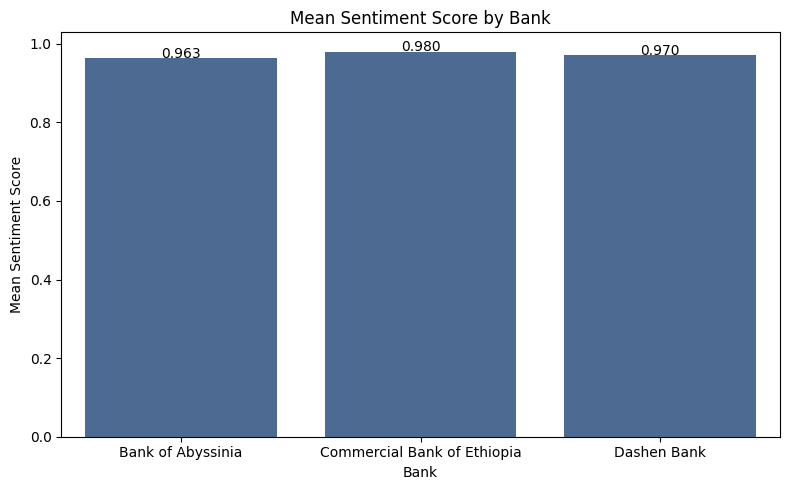

In [7]:
# Plot bar chart
plt.figure(figsize=(8, 5))

ax = bank_sentiment.plot(kind="bar")
bars = ax.bar(
    bank_sentiment.index,
    bank_sentiment.values,
    color="#4C6A92"
)
for i, value in enumerate(bank_sentiment):
    ax.text(
        i,                      # x position
        value + 0.001,          # y position
        f"{value:.3f}",         # text label
        ha='center'
    )
plt.title("Mean Sentiment Score by Bank")
plt.xlabel("Bank")
plt.ylabel("Mean Sentiment Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Sentiment by Star Rating

In [8]:
rating_sentiment = df.groupby("rating")["confidence_score"].mean()

print(rating_sentiment)
rating_sentiment

rating
1    0.981099
2    0.977560
3    0.970904
4    0.959108
5    0.969409
Name: confidence_score, dtype: float64


rating
1    0.981099
2    0.977560
3    0.970904
4    0.959108
5    0.969409
Name: confidence_score, dtype: float64

0 0.981067436447471
1 0.9764014448438372
2 0.971672106796587
3 0.958388386964798
4 0.9696881319940795


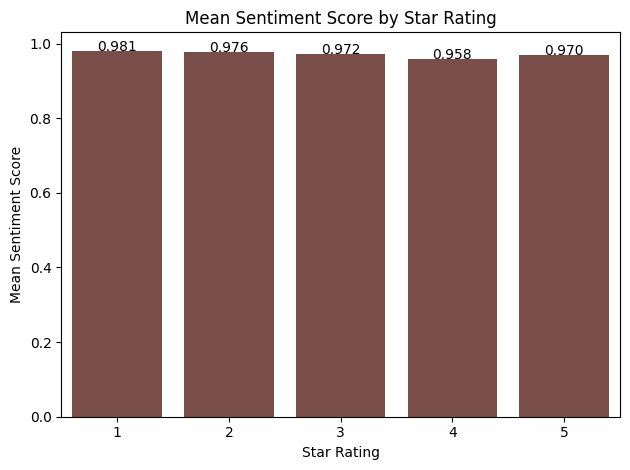

In [44]:
# Plot bars
ax = rating_sentiment.plot(kind="bar")
bars = ax.bar(
    rating_sentiment.index.astype(str),
    rating_sentiment.values,
    color="#7A4E48"
)
# Add values on top of bars
for i, value in enumerate(rating_sentiment):
    print(i,value)
    ax.text(
        i,
        value,
        f"{value:.3f}",
        ha='center'
    )

# Titles and labels
plt.title("Mean Sentiment Score by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Mean Sentiment Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

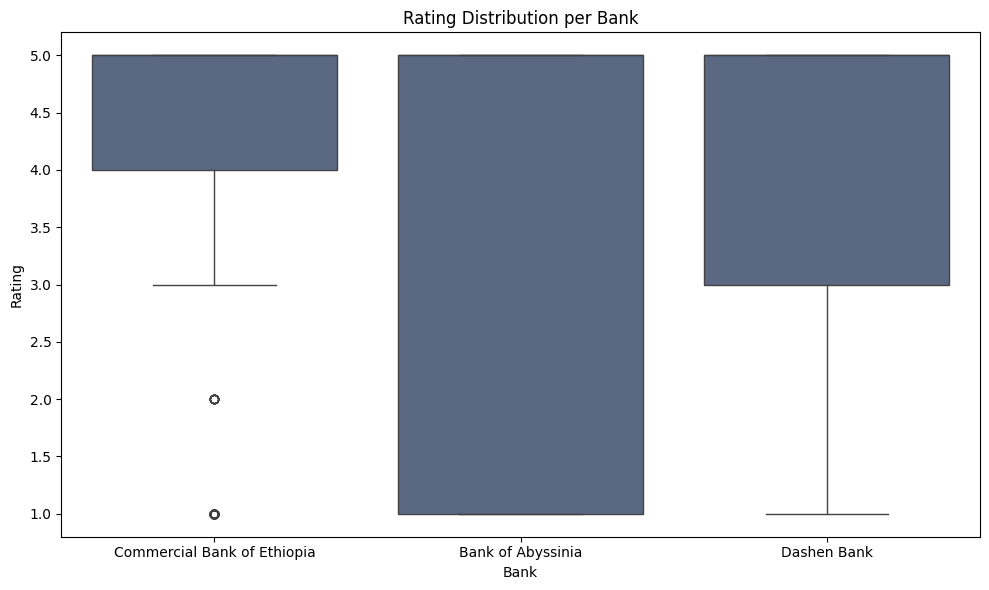

In [23]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='bank',
    y='rating',
    color= "#546787"
)

plt.title('Rating Distribution per Bank')
plt.xlabel('Bank')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()


The boxplot shows that Commercial Bank of Ethiopia (CBE) maintained the most consistent high ratings, with most reviews concentrated between ratings 4 and 5. This suggests stronger customer satisfaction and a more stable user experience, despite a few low-rating outliers.

Dashen Bank also received relatively high ratings, although the wider spread indicates more variation in customer experience and satisfaction levels.

Bank of Abyssinia displayed the widest rating distribution, ranging heavily from 1 to 5, which reflects mixed customer experiences and a higher level of dissatisfaction compared to the other banks.

Overall, the visualization indicates that CBE achieved the strongest rating consistency, while BOA experienced the greatest variability in user feedback.

## Insights and Recommendations

In [11]:
dff = load_data("../data/processed/bank_reviews_theme.csv")

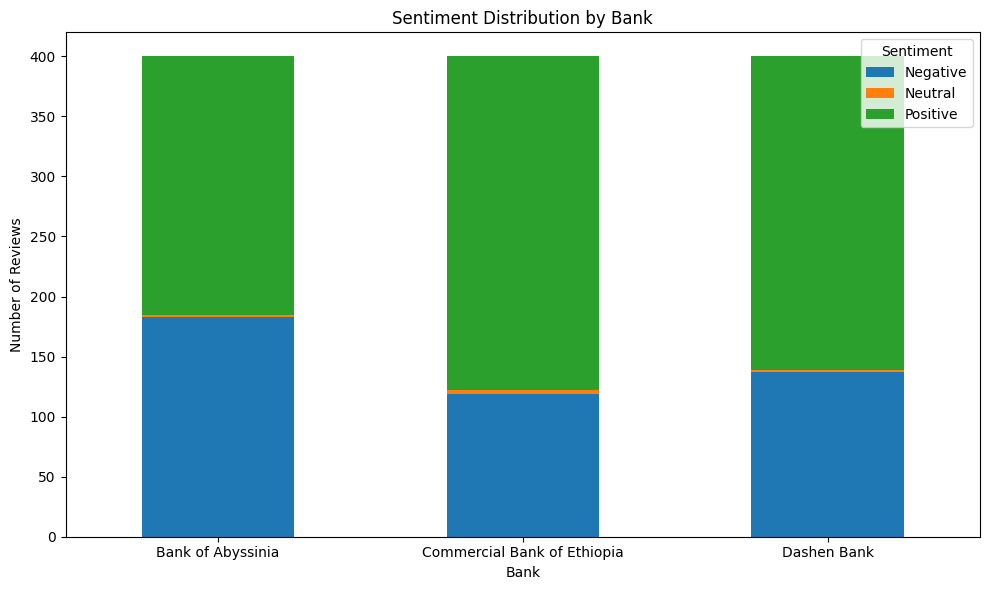

In [12]:
# Sentiment distribution
sentiment_counts = pd.crosstab(dff['bank'], dff['sentiment_label'])

sentiment_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Sentiment Distribution by Bank')
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

### Sentiment Distribution by Bank

Positive sentiment dominated across all three banks, showing generally favorable customer experiences with mobile banking services. Commercial Bank of Ethiopia (CBE) recorded the strongest positive sentiment and the lowest negative feedback, indicating higher customer satisfaction and better app reliability.

Dashen Bank also received strong positive feedback but showed slightly more negative reviews related to performance and account access issues. Bank of Abyssinia had the highest proportion of negative sentiment, suggesting more frequent technical and stability problems.

Overall, the visualization highlights that app performance and reliability were the main factors influencing customer satisfaction across the banks.

### Rating distribution per bank

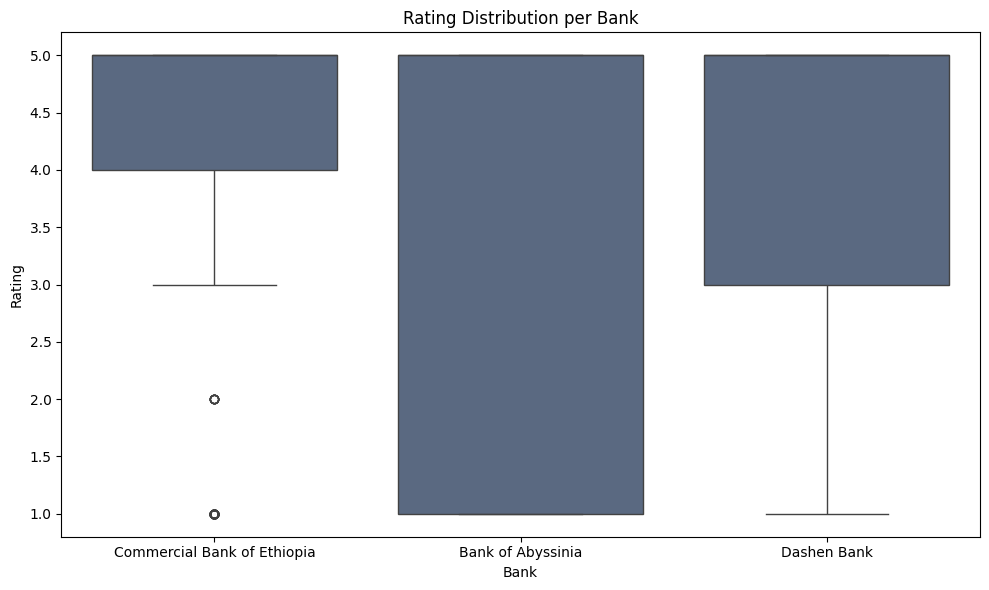

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=dff,
    x='bank',
    y='rating',
    color= "#546787"
)

plt.title('Rating Distribution per Bank')
plt.xlabel('Bank')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

## Sentiment trend over time

In [ ]:
sentiment_trend = (
    df.groupby(["date", "bank"])["confidence_score"]
    .mean()
    .reset_index()
)

# Rename column
sentiment_trend = sentiment_trend.rename(columns={
    "confidence_score": "avg_sentiment_score"
})

pivot_df = sentiment_trend.pivot(
    index="date",
    columns="bank",
    values="avg_sentiment_score"
)


         date         bank  avg_sentiment_score
0  2023-04-13  Dashen Bank             0.999794
1  2023-04-18  Dashen Bank             0.999816
2  2023-04-28  Dashen Bank             0.999674
3  2023-05-04  Dashen Bank             0.999794
4  2023-05-05  Dashen Bank             0.949920


datetime64[us]


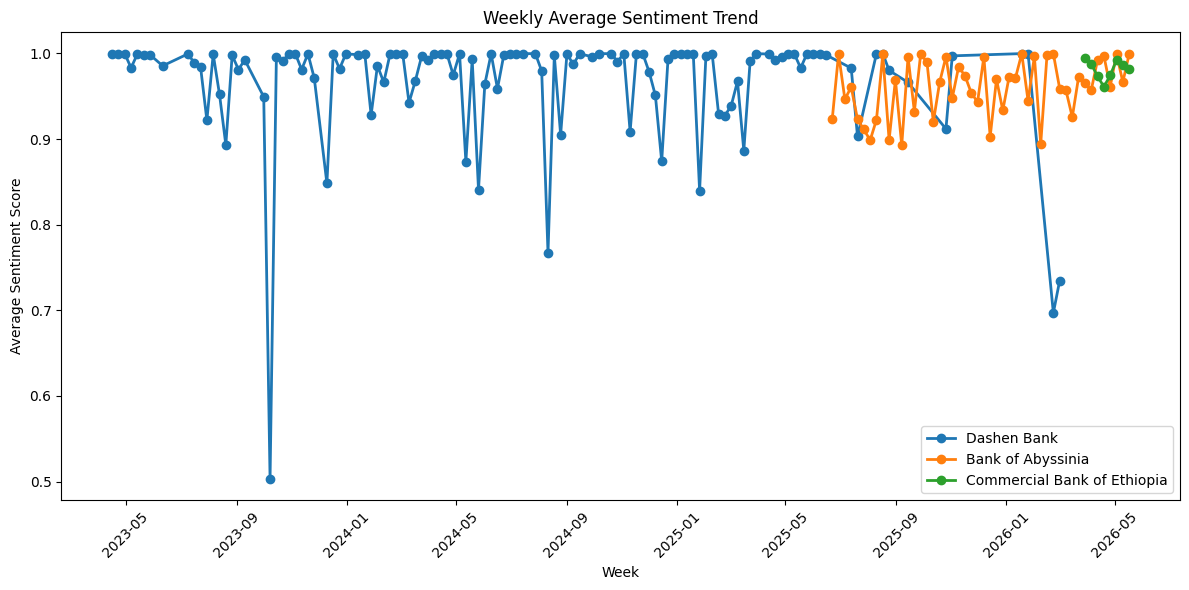

In [ ]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dtype)
weekly_sentiment = (
    df.groupby(
        [
            pd.Grouper(
                key="date",
                freq="W"
            ),
            "bank"
        ]
    )["confidence_score"]
    .mean()
    .reset_index()
)


plt.figure(figsize=(12, 6))

for bank in weekly_sentiment["bank"].unique():

    bank_data = weekly_sentiment[
        weekly_sentiment["bank"] == bank
    ]

    plt.plot(
        bank_data["date"],
        bank_data["confidence_score"],
        marker='o',
        linewidth=2,
        label=bank
    )

plt.title("Weekly Average Sentiment Trend")
plt.xlabel("Week")
plt.ylabel("Average Sentiment Score")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()